# MODELO KMEANS PARA CLASIFICACIÓN DE CLIENTES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?resource=download)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dev0914sharma/customer-clustering")

print("Path to dataset files:", path)

100%|██████████| 25.9k/25.9k [00:00<00:00, 34.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1


In [4]:
dataset_path = '/root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1/segmentation data.csv'

In [6]:
df = pd.read_csv(dataset_path)
df.head(4)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1


# EDA

In [7]:
df.dtypes

,0
ID,int64
Sex,int64
Marital status,int64
Age,int64
Education,int64
Income,int64
Occupation,int64
Settlement size,int64


# VERIFICAMOS NULOS Y DUPLICADOS

In [8]:
df.isnull().sum().sum()

0

In [9]:
df.duplicated().sum()

0

In [10]:
df.shape

(2000, 8)

# BUSCAMOS OUTLIERS

In [11]:
from scipy.stats import zscore

z_scores = df.apply(zscore)

outliers = (z_scores.abs() > 3).sum()

outliers

,0
ID,0
Sex,0
Marital status,0
Age,11
Education,36
Income,31
Occupation,0
Settlement size,0


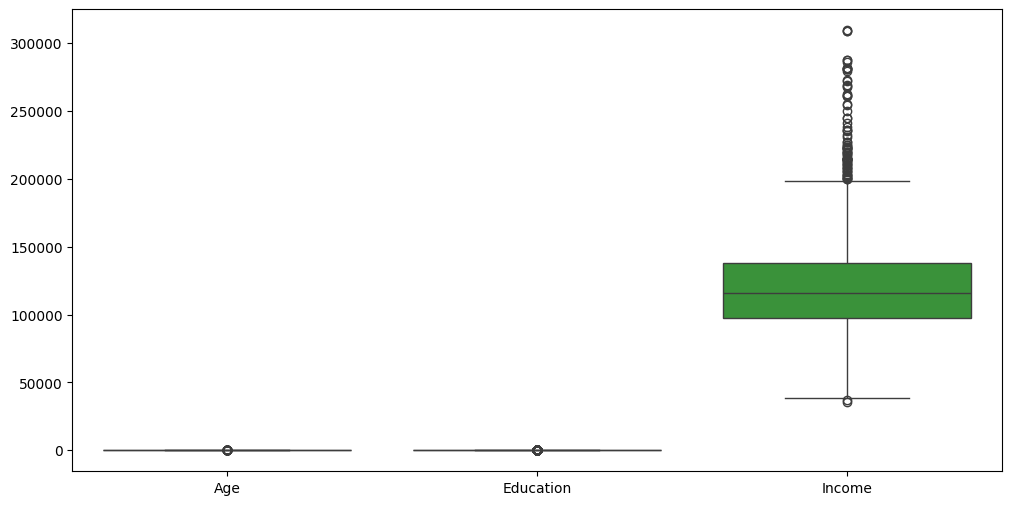

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Age','Education','Income']])
plt.show()

In [13]:
df_cleaned = df[
    (z_scores['Age'].abs() <= 3) &
    (z_scores['Education'].abs() <= 3) &
    (z_scores['Income'].abs() <= 3)
].copy()
df_cleaned.shape

(1926, 8)

# ELIMINAMOS COLUMNAS INNECESARIAS

In [14]:
df_cleaned.drop(columns=['ID'],inplace=True)
df_cleaned.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


# ESCALAMOS VALORES

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned),columns=df_cleaned.columns)
df_scaled.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,-0.914349,-0.984543,2.922191,1.890530,0.205631,0.341882,1.586400
1,1.093674,1.015700,-1.214322,0.015576,0.998166,0.341882,1.586400
2,-0.914349,-0.984543,1.267586,0.015576,-0.871000,-1.264131,-0.891626
3,-0.914349,-0.984543,0.899896,0.015576,1.629450,0.341882,0.347387
4,-0.914349,-0.984543,1.635276,0.015576,0.945276,0.341882,0.347387


# APLICANDO MODELO KMEANS